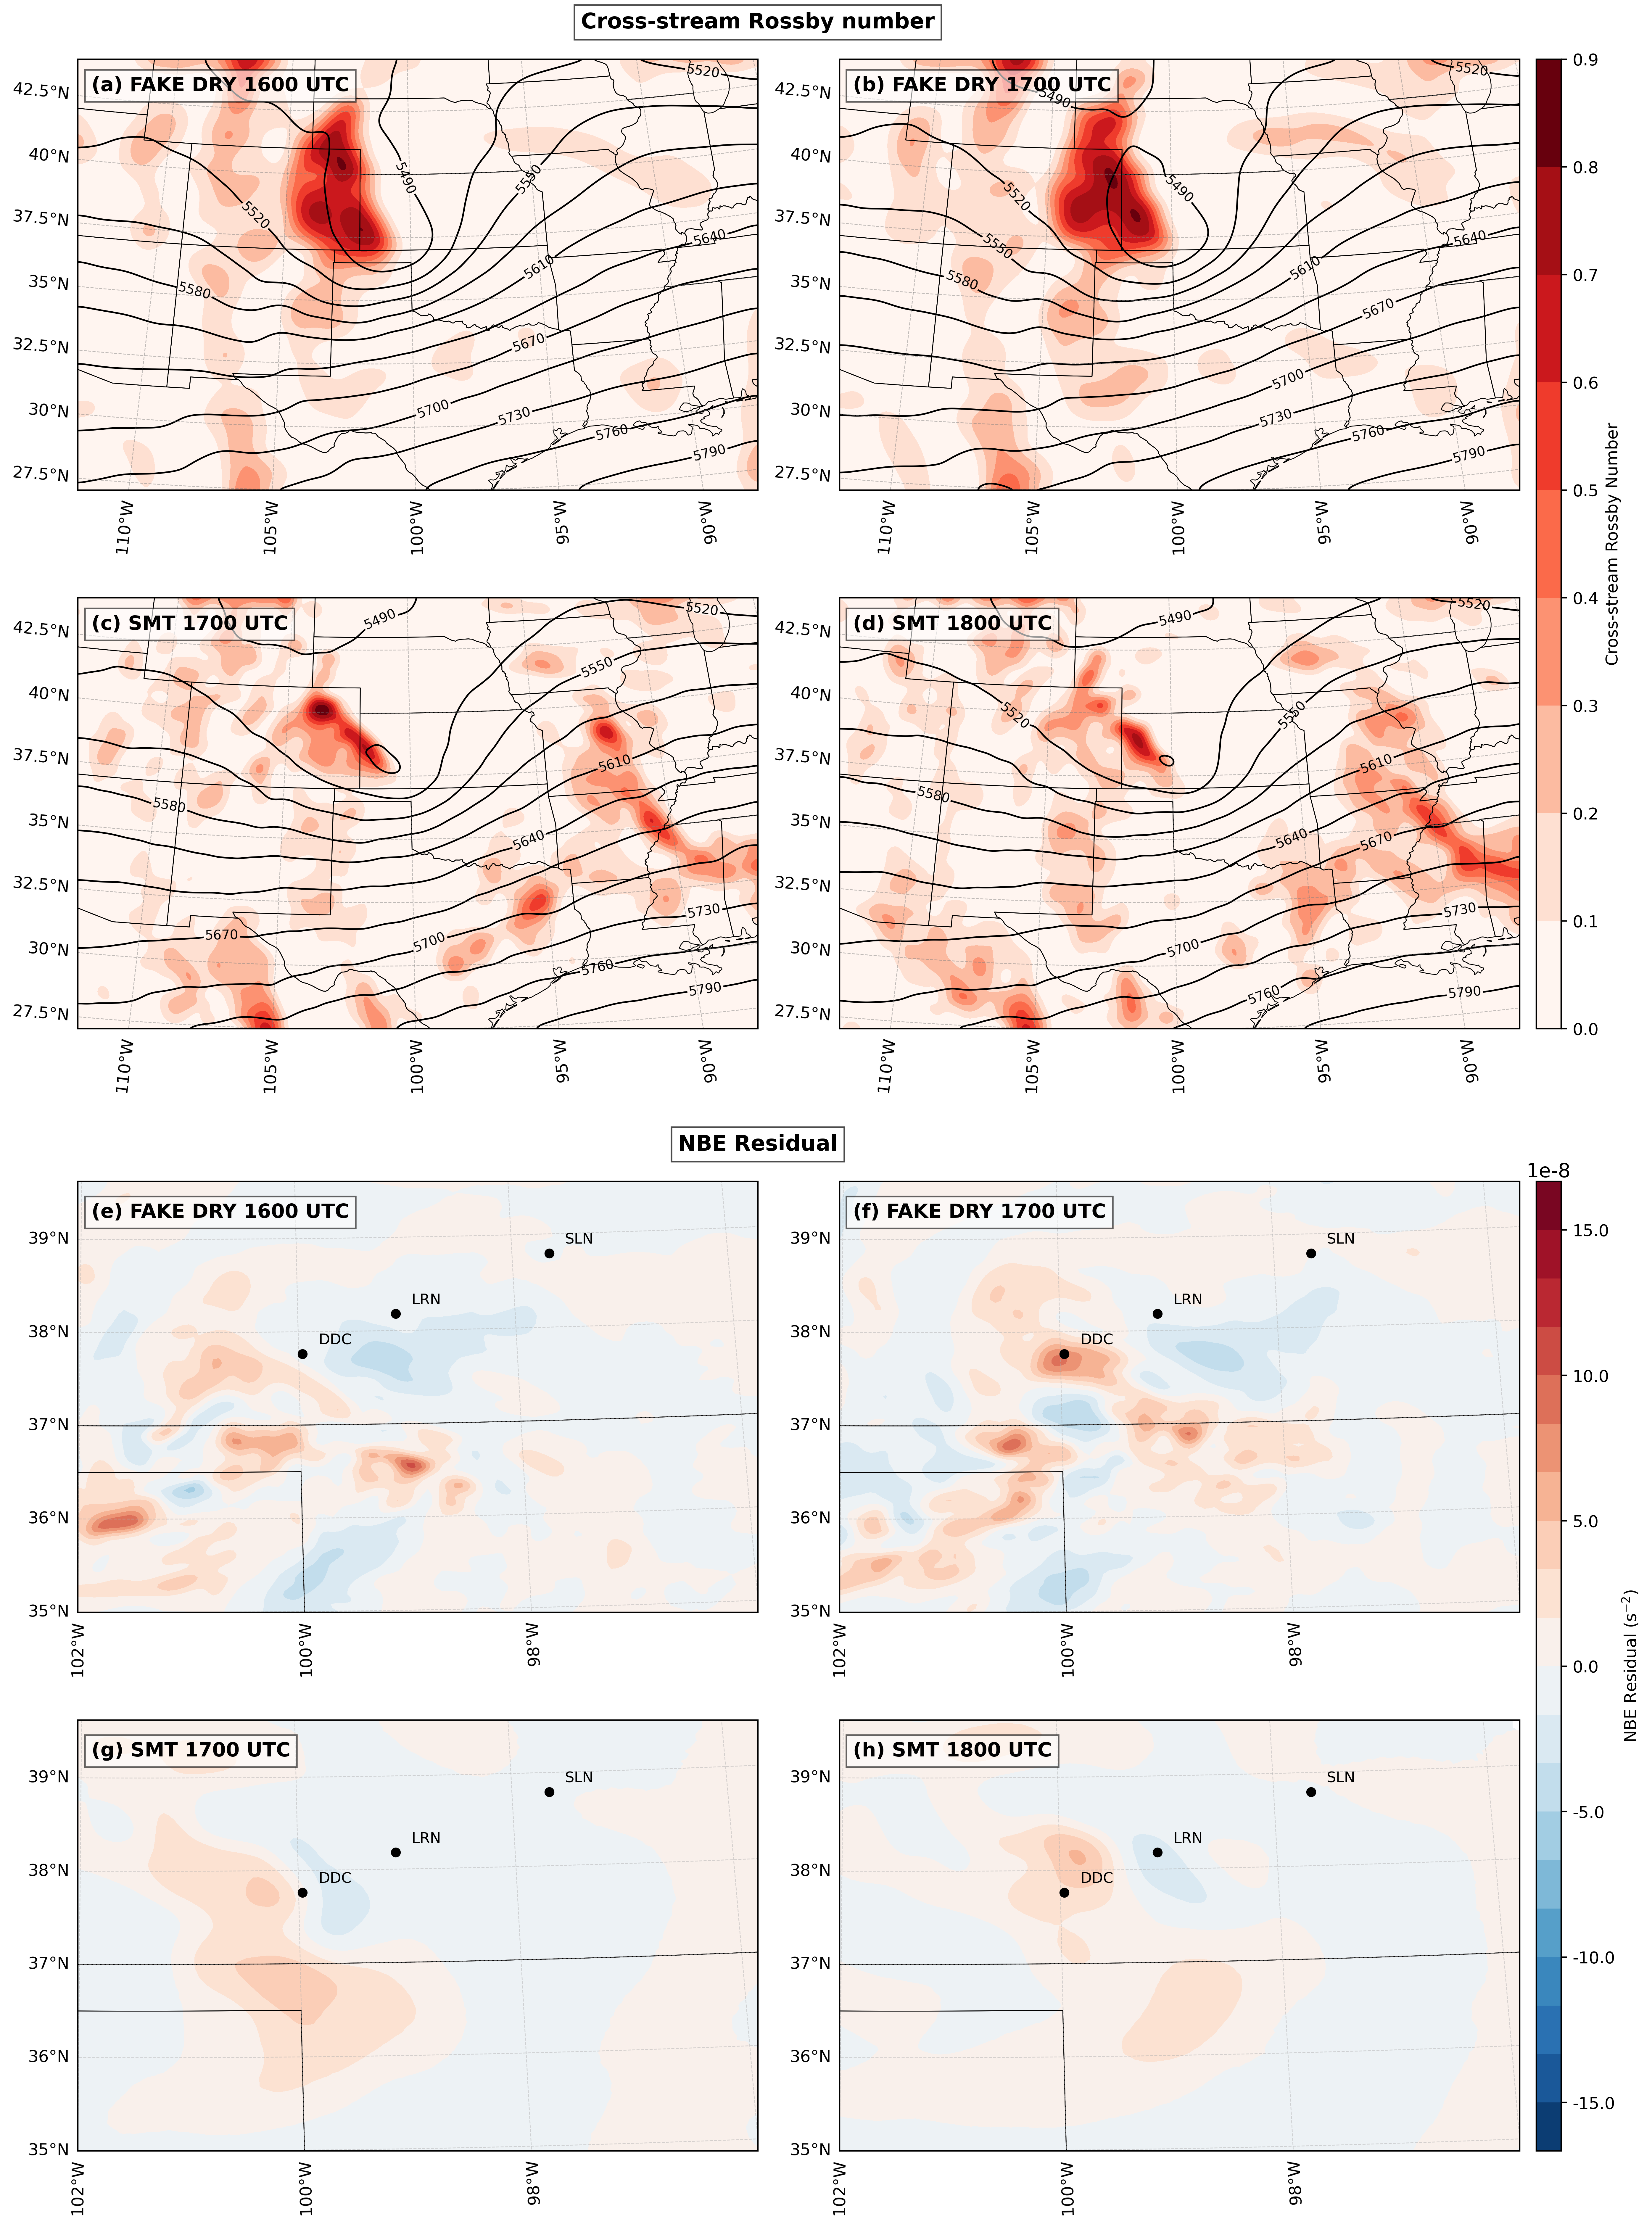

In [1]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as crs
from cartopy.feature import STATES, BORDERS
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from wrf import getvar, interplevel, to_np, latlon_coords, get_cartopy
from scipy.ndimage import gaussian_filter
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import FuncFormatter, FixedLocator

R_earth = 6371000.0
g = 9.81
omega = 7.2921e-5

FIGSIZE = (14, 19)

LEFT, RIGHT = 0.05, 0.92
BOTTOM, TOP = 0.05, 0.96

WSPACE = 0.12
HSPACE = 0.25
SECTION_GAP = 0.02

EXTENT = [-102, -96, 35, 39.5]

DDC_LAT, DDC_LON = 37.7636, -99.9656
LRN_LAT, LRN_LON = 38.1806, -99.0996
SLN_LAT, SLN_LON = 38.7910, -97.6522

SMT_SMOOTHING = {
    "rossby_z": 5,
    "rossby_ro": 6,
    "nbe_phi": 14,
    "nbe_u": 5,
    "nbe_v": 5,
}

FAKEDRY_SMOOTHING = {
    "rossby_z": 8,
    "rossby_ro": 10,
    "nbe_phi": 8,
    "nbe_u": 1.5,
    "nbe_v": 1.5,
}

smt_times = ["17:00:00", "18:00:00"]
smt_files = [
    f"/glade/derecho/scratch/rbhandari/SMOOTH-Terrain1/wrfv4.6.1/test/em_real/wrfout_d02_1992-02-14_{t}"
    for t in smt_times
]

fakedry_dataDir = "/glade/work/rbhandari/data/SIM_Feb14_MP2_Fakedry"
fakedry_times = ["16:00:00", "17:00:00"]
fakedry_files = [
    f"{fakedry_dataDir}/wrfout_d02_1992-02-14_{t}"
    for t in fakedry_times
]

def nan_gaussian_filter(data, sigma):
    nan_mask = np.isnan(data)
    data_filled = np.where(nan_mask, 0.0, data)
    weights = (~nan_mask).astype(float)

    smoothed = gaussian_filter(data_filled, sigma=sigma)
    smoothed_w = gaussian_filter(weights, sigma=sigma)

    return np.where(smoothed_w == 0, np.nan, smoothed / smoothed_w)

def apply_gridlines_rossby(ax):
    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    return gl

def apply_gridlines_nbe(ax):
    gl = ax.gridlines(
        draw_labels=True,
        dms=False,
        x_inline=False,
        y_inline=False,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5,
    )

    gl.xlocator = FixedLocator(np.arange(-180, 181, 2))
    gl.ylocator = FixedLocator(np.arange(-90, 91, 1))

    gl.top_labels = False
    gl.right_labels = False

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    return gl

def process_rossby(filepath, smoothing):
    nc = Dataset(filepath)

    p = getvar(nc, "pressure")
    z = getvar(nc, "z", units="m")
    u = getvar(nc, "ua", units="m s-1")
    v = getvar(nc, "va", units="m s-1")

    z500 = interplevel(z, p, 500)
    u500 = interplevel(u, p, 500)
    v500 = interplevel(v, p, 500)

    z_np = to_np(z500)
    u_np = to_np(u500)
    v_np = to_np(v500)

    z_smooth = nan_gaussian_filter(z_np, sigma=smoothing["rossby_z"])

    lats, lons = latlon_coords(z500)
    lat = to_np(lats)
    lon = to_np(lons)

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    dlat = np.gradient(lat_rad, axis=0)
    dlon = np.gradient(lon_rad, axis=1)

    dy = R_earth * dlat
    dx = R_earth * np.cos(lat_rad) * dlon

    f_raw = 2 * omega * np.sin(lat_rad)
    f = np.where(np.abs(f_raw) < 1e-8, 1e-8, f_raw)

    dz_dy = np.gradient(z_smooth, axis=0) / dy
    dz_dx = np.gradient(z_smooth, axis=1) / dx

    ug = -g / f * dz_dy
    vg = g / f * dz_dx

    uag = u_np - ug
    vag = v_np - vg

    Vgmag = np.sqrt(ug**2 + vg**2)
    Vgmag_safe = np.where(Vgmag < 1e-8, np.nan, Vgmag)

    t_x = ug / Vgmag_safe
    t_y = vg / Vgmag_safe

    nL_x = -t_y
    nL_y = t_x

    Vag_left = uag * nL_x + vag * nL_y
    Vag_left_cyclonic = np.where(Vag_left > 0.0, Vag_left, 0.0)

    Vmag = np.sqrt(u_np**2 + v_np**2)
    Vmag = np.where(Vmag < 1e-8, 1e-8, Vmag)

    Ro_cs = Vag_left_cyclonic / Vmag
    Ro_cs = nan_gaussian_filter(Ro_cs, sigma=smoothing["rossby_ro"])

    nc.close()

    return lon, lat, Ro_cs, z_smooth, z500

def process_nbe(filepath, smoothing):
    nc = Dataset(filepath)

    p = getvar(nc, "pressure")
    z = getvar(nc, "z", units="m")
    phi = g * z

    u = getvar(nc, "ua", units="m/s")
    v = getvar(nc, "va", units="m/s")

    z500 = interplevel(z, p, 500)
    phi500 = interplevel(phi, p, 500)
    u500 = interplevel(u, p, 500)
    v500 = interplevel(v, p, 500)

    phi_s = gaussian_filter(to_np(phi500), sigma=smoothing["nbe_phi"])
    u_s = gaussian_filter(to_np(u500), sigma=smoothing["nbe_u"])
    v_s = gaussian_filter(to_np(v500), sigma=smoothing["nbe_v"])

    lats, lons = latlon_coords(z500)
    lat = np.deg2rad(to_np(lats))
    lon = np.deg2rad(to_np(lons))

    dx = R_earth * np.cos(lat) * np.gradient(lon, axis=1)
    dy = R_earth * np.gradient(lat, axis=0)

    f = 2 * omega * np.sin(lat)
    f = np.where(np.abs(f) < 1e-8, 1e-8, f)

    dphi_dx = np.gradient(phi_s, axis=1) / dx
    dphi_dy = np.gradient(phi_s, axis=0) / dy

    lap_phi = (
        np.gradient(dphi_dx, axis=1) / dx
        + np.gradient(dphi_dy, axis=0) / dy
    )

    du_dx = np.gradient(u_s, axis=1) / dx
    dv_dy = np.gradient(v_s, axis=0) / dy
    dv_dx = np.gradient(v_s, axis=1) / dx
    du_dy = np.gradient(u_s, axis=0) / dy

    zeta = dv_dx - du_dy
    J = du_dx * dv_dy - dv_dx * du_dy

    dyn = 2 * J + f * zeta
    pres = -lap_phi
    res = dyn + pres

    nc.close()

    return to_np(lons), to_np(lats), res, z500

smt_rossby_data = [
    process_rossby(f, SMT_SMOOTHING)
    for f in smt_files
]

smt_nbe_data = [
    process_nbe(f, SMT_SMOOTHING)
    for f in smt_files
]

fakedry_rossby_data = [
    process_rossby(f, FAKEDRY_SMOOTHING)
    for f in fakedry_files
]

fakedry_nbe_data = [
    process_nbe(f, FAKEDRY_SMOOTHING)
    for f in fakedry_files
]

proj = get_cartopy(smt_rossby_data[0][-1])

ro_bounds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
ro_cmap = plt.get_cmap("Reds", len(ro_bounds) - 1)
ro_norm = mcolors.BoundaryNorm(ro_bounds, ro_cmap.N)

RES_MIN = -16.67e-8
RES_MAX = 16.67e-8
res_levels = np.linspace(RES_MIN, RES_MAX, 21)

exp_forced = -8
scale = 10.0 ** exp_forced
fmt = FuncFormatter(lambda v, _: f"{v / scale:.1f}")

fig, axes = plt.subplots(
    4,
    2,
    figsize=FIGSIZE,
    dpi=400,
    subplot_kw={"projection": proj}
)

plt.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    bottom=BOTTOM,
    top=TOP,
    wspace=WSPACE,
    hspace=HSPACE
)

for ax in axes.flat:
    ax.set_aspect("auto")

fakedry_rossby_titles = ["(a) FAKE DRY 1600 UTC", "(b) FAKE DRY 1700 UTC"]
smt_rossby_titles = ["(c) SMT 1700 UTC", "(d) SMT 1800 UTC"]

fakedry_nbe_titles = ["(e) FAKE DRY 1600 UTC", "(f) FAKE DRY 1700 UTC"]
smt_nbe_titles = ["(g) SMT 1700 UTC", "(h) SMT 1800 UTC"]

def plot_rossby_row(ax_row, data_list, title_list):
    for ax, data, title in zip(ax_row, data_list, title_list):
        lon, lat, Ro, zf, _ = data

        ax.contourf(
            lon,
            lat,
            Ro,
            levels=ro_bounds,
            cmap=ro_cmap,
            norm=ro_norm,
            transform=crs.PlateCarree()
        )

        cs = ax.contour(
            lon,
            lat,
            zf,
            levels=np.arange(
                np.nanmin(zf) // 30 * 30,
                np.nanmax(zf) // 30 * 30 + 30,
                30
            ),
            colors="black",
            linewidths=1,
            transform=crs.PlateCarree()
        )

        ax.clabel(cs, fmt="%d", fontsize=8)

        ax.add_feature(STATES, linewidth=0.5)
        ax.add_feature(BORDERS, linewidth=0.5)

        apply_gridlines_rossby(ax)

        ax.text(
            0.02,
            0.96,
            title,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(facecolor="white", alpha=0.6)
        )

def plot_nbe_row(ax_row, data_list, title_list):
    row_mappable = None

    for ax, data, title in zip(ax_row, data_list, title_list):
        lons, lats, res, _ = data

        mappable = ax.contourf(
            lons,
            lats,
            res,
            levels=res_levels,
            cmap="RdBu_r",
            transform=crs.PlateCarree(),
            extend="neither"
        )

        if row_mappable is None:
            row_mappable = mappable

        ax.add_feature(STATES, linewidth=0.5)
        ax.add_feature(BORDERS, linewidth=0.5)

        ax.set_extent(EXTENT, crs=crs.PlateCarree())
        apply_gridlines_nbe(ax)

        for lon0, lat0, lab in [
            (DDC_LON, DDC_LAT, "DDC"),
            (LRN_LON, LRN_LAT, "LRN"),
            (SLN_LON, SLN_LAT, "SLN")
        ]:
            ax.plot(
                lon0,
                lat0,
                marker="o",
                markersize=5,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=1.0,
                transform=crs.PlateCarree(),
                zorder=6
            )

            ax.text(
                lon0 + 0.15,
                lat0 + 0.10,
                lab,
                fontsize=9,
                transform=crs.PlateCarree(),
                zorder=6
            )

        ax.text(
            0.02,
            0.95,
            title,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top",
            bbox=dict(facecolor="white", alpha=0.6)
        )

    return row_mappable

plot_rossby_row(axes[0], fakedry_rossby_data, fakedry_rossby_titles)
plot_rossby_row(axes[1], smt_rossby_data, smt_rossby_titles)

fakedry_nbe_mappable = plot_nbe_row(axes[2], fakedry_nbe_data, fakedry_nbe_titles)
smt_nbe_mappable = plot_nbe_row(axes[3], smt_nbe_data, smt_nbe_titles)

for j in range(2):
    pos = axes[2, j].get_position()
    axes[2, j].set_position([pos.x0, pos.y0 - SECTION_GAP, pos.width, pos.height])

    pos = axes[3, j].get_position()
    axes[3, j].set_position([pos.x0, pos.y0 - SECTION_GAP, pos.width, pos.height])

axes[0, 0].text(
    1.0,
    1.11,
    "Cross-stream Rossby number",
    transform=axes[0, 0].transAxes,
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7),
    zorder=10
)

axes[2, 0].text(
    1.0,
    1.11,
    "NBE Residual",
    transform=axes[2, 0].transAxes,
    fontsize=13,
    fontweight="bold",
    ha="center",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7),
    zorder=10
)

ro_mappable = ScalarMappable(norm=ro_norm, cmap=ro_cmap)
ro_mappable.set_array([])

fig.canvas.draw()

CBAR_WIDTH = 0.015
CBAR_PAD = 0.01

pos_rossby_top = axes[0, 1].get_position()
pos_rossby_bottom = axes[1, 1].get_position()
pos_nbe_top = axes[2, 1].get_position()
pos_nbe_bottom = axes[3, 1].get_position()

CBAR_LEFT = pos_rossby_top.x1 + CBAR_PAD

rossby_y0 = pos_rossby_bottom.y0
rossby_y1 = pos_rossby_top.y1
rossby_height = rossby_y1 - rossby_y0

nbe_y0 = pos_nbe_bottom.y0
nbe_y1 = pos_nbe_top.y1
nbe_height = nbe_y1 - nbe_y0

cax_ro = fig.add_axes([CBAR_LEFT, rossby_y0, CBAR_WIDTH, rossby_height])
cb_ro = fig.colorbar(ro_mappable, cax=cax_ro)
cb_ro.set_label("Cross-stream Rossby Number")

cax_nbe = fig.add_axes([CBAR_LEFT, nbe_y0, CBAR_WIDTH, nbe_height])
cb_nbe = fig.colorbar(fakedry_nbe_mappable, cax=cax_nbe)
cb_nbe.set_label("NBE Residual (s$^{-2}$)")
cb_nbe.ax.yaxis.set_major_formatter(fmt)
cb_nbe.ax.set_title("1e-8", pad=2)

plt.savefig("SMT-FD-QJRMS.png", dpi=600, bbox_inches="tight")
plt.show()